# Import Libraries

In [1]:
import copy
import itertools
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch_geometric.nn import GCNConv, MessagePassing
from torch_geometric.utils import add_self_loops

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

from tqdm import trange

print('Imports OK')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA avail: {torch.cuda.is_available()}')

Imports OK
PyTorch  : 2.6.0+cu124
CUDA avail: True


# Class imbalance in BRCA data

=== Class Distribution ===
              Count  Percentage (%)
vital.status                       
0               611           86.67
1                94           13.33

Imbalance Ratio: 6.50:1


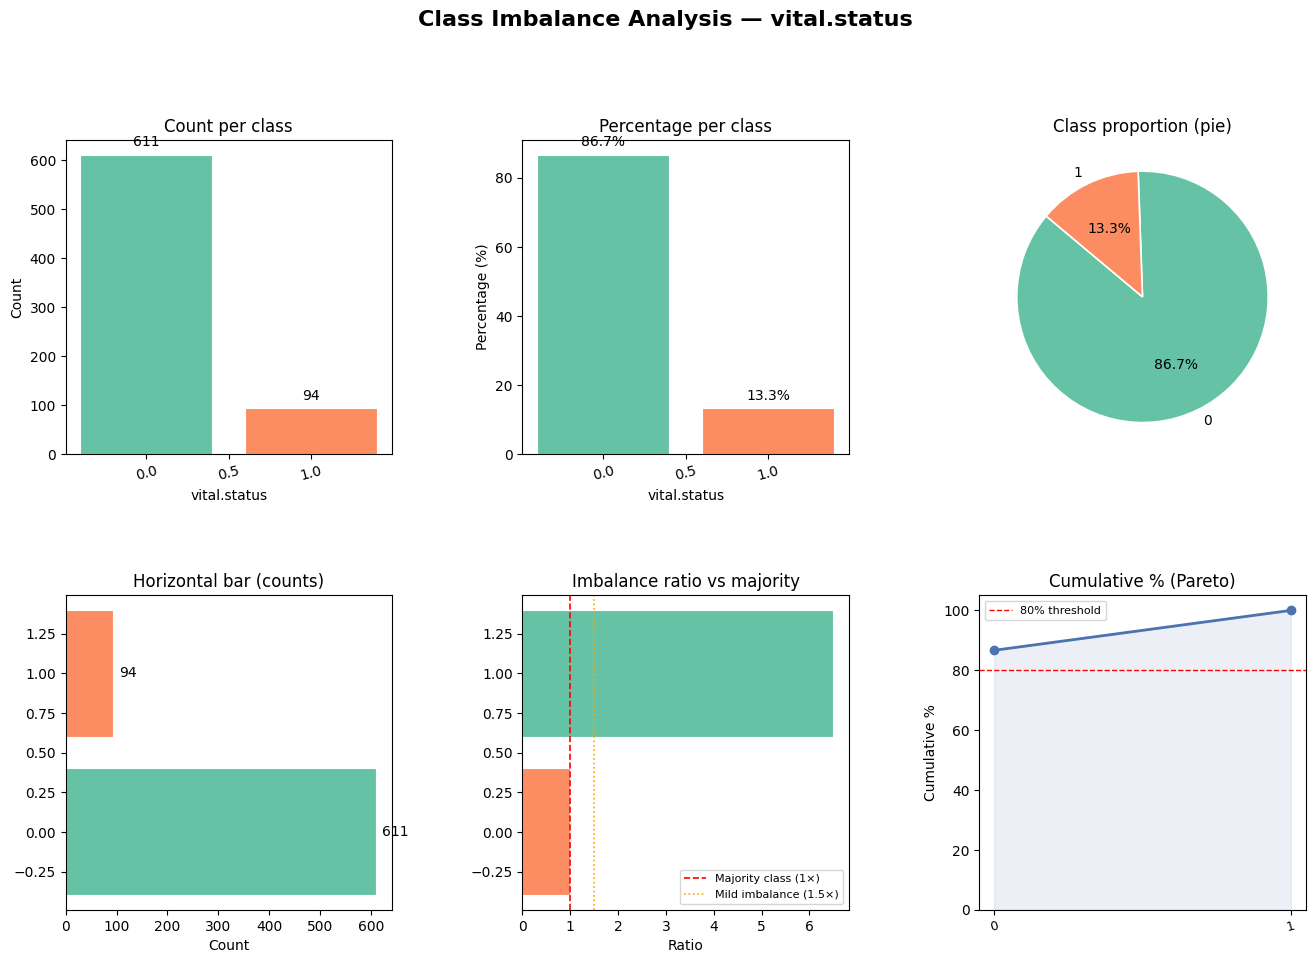


Plot saved as class_imbalance.png

=== Imbalance Severity ===
⚠️  Moderate imbalance (ratio 6.50:1) — Try SMOTE / oversampling.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Load data
data = pd.read_csv("data.csv")

# Basic counts & percentages
vc = data["vital.status"].value_counts()
pct = data["vital.status"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"Count": vc, "Percentage (%)": pct.round(2)})
print("=== Class Distribution ===")
print(summary)
print(f"\nImbalance Ratio: {vc.max() / vc.min():.2f}:1")

# Plots
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Class Imbalance Analysis — vital.status", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

colors = plt.cm.Set2.colors[:len(vc)]

# Bar chart (counts)
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(vc.index, vc.values, color=colors, edgecolor="white", linewidth=0.8)
ax1.bar_label(bars, fmt="%d", padding=4, fontsize=10)
ax1.set_title("Count per class", fontsize=12)
ax1.set_xlabel("vital.status")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=15)

# Bar chart (percentage)
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(pct.index, pct.values, color=colors, edgecolor="white", linewidth=0.8)
ax2.bar_label(bars2, fmt="%.1f%%", padding=4, fontsize=10)
ax2.set_title("Percentage per class", fontsize=12)
ax2.set_xlabel("vital.status")
ax2.set_ylabel("Percentage (%)")
ax2.tick_params(axis="x", rotation=15)

# Pie chart
ax3 = fig.add_subplot(gs[0, 2])
wedges, texts, autotexts = ax3.pie(
    vc.values,
    labels=vc.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.2),
)
for t in autotexts:
    t.set_fontsize(10)
ax3.set_title("Class proportion (pie)", fontsize=12)

# Horizontal bar 
ax4 = fig.add_subplot(gs[1, 0])
hbars = ax4.barh(vc.index, vc.values, color=colors, edgecolor="white", linewidth=0.8)
ax4.bar_label(hbars, fmt="%d", padding=4, fontsize=10)
ax4.set_title("Horizontal bar (counts)", fontsize=12)
ax4.set_xlabel("Count")

# Imbalance ratio reference line
ax5 = fig.add_subplot(gs[1, 1])
ratios = (vc.max() / vc).sort_values()
ax5.barh(ratios.index, ratios.values, color=colors[::-1], edgecolor="white", linewidth=0.8)
ax5.axvline(x=1, color="red", linestyle="--", linewidth=1.2, label="Majority class (1×)")
ax5.axvline(x=1.5, color="orange", linestyle=":", linewidth=1.2, label="Mild imbalance (1.5×)")
ax5.set_title("Imbalance ratio vs majority", fontsize=12)
ax5.set_xlabel("Ratio")
ax5.legend(fontsize=8)

# Cumulative distribution
ax6 = fig.add_subplot(gs[1, 2])
sorted_vc = vc.sort_values(ascending=False)
cumsum_pct = (sorted_vc.cumsum() / sorted_vc.sum() * 100)
ax6.plot(range(len(cumsum_pct)), cumsum_pct.values, marker="o", color="#4c72b0", linewidth=2)
ax6.axhline(y=80, color="red", linestyle="--", linewidth=1, label="80% threshold")
ax6.set_xticks(range(len(cumsum_pct)))
ax6.set_xticklabels(cumsum_pct.index, rotation=15, fontsize=9)
ax6.set_title("Cumulative % (Pareto)", fontsize=12)
ax6.set_ylabel("Cumulative %")
ax6.set_ylim(0, 105)
ax6.legend(fontsize=8)
ax6.fill_between(range(len(cumsum_pct)), cumsum_pct.values, alpha=0.1, color="#4c72b0")

plt.savefig("class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as class_imbalance.png")

# Imbalance severity assessment
ratio = vc.max() / vc.min()
print("\n=== Imbalance Severity ===")
if ratio < 1.5:
    print(f" Balanced  (ratio {ratio:.2f}:1) — No special handling needed.")
elif ratio < 3:
    print(f" Mild imbalance (ratio {ratio:.2f}:1) — Consider class_weight='balanced'.")
elif ratio < 10:
    print(f" Moderate imbalance (ratio {ratio:.2f}:1) — Try SMOTE / oversampling.")
else:
    print(f" Severe imbalance (ratio {ratio:.2f}:1) — Use SMOTE, undersampling, or anomaly detection approach.")

# SMOTE to balance the classes

In [3]:
import pandas as pd
from imblearn.over_sampling import SMOTE

data = pd.read_csv("data.csv")


X = data.drop(columns=["vital.status"])   # shape: (705, 1936)
y = data["vital.status"]                   # 0 → 611, 1 → 94

# SMOTE synthesises new minority rows by interpolating between a real sample and k of its nearest neighbours
smote = SMOTE(
    sampling_strategy=1.0,  # fully balanced,
    k_neighbors=5,           # neighbours to use per synthetic point
    random_state=42
)
X_res, y_res = smote.fit_resample(X, y)

# rebuild full dataframe with all original columns
df_smote = pd.DataFrame(X_res, columns=X.columns)
df_smote["vital.status"] = y_res

print(df_smote["vital.status"].value_counts())
print(f"Shape: {df_smote.shape}")

df_smote.to_csv("data_smote.csv", index=False)

vital.status
0    611
1    611
Name: count, dtype: int64
Shape: (1222, 1937)


# BRCA Data Preprocessing

In [4]:
# Load 
data  = pd.read_csv('data_smote.csv')
y_raw = data['vital.status'].values
X_raw = data.drop(columns=['vital.status'])

# Normalise 
X_norm = pd.DataFrame(StandardScaler().fit_transform(X_raw), columns=X_raw.columns)
X_np   = X_norm.values  # (n_samples, n_genes)

# Split genes into omics-like partitions 
K           = 3
gene_splits = np.array_split(np.arange(X_np.shape[1]), K)
X_mut  = torch.tensor(X_np[:, gene_splits[0]], dtype=torch.float32)
X_cnv  = torch.tensor(X_np[:, gene_splits[1]], dtype=torch.float32)
X_expr = torch.tensor(X_np[:, gene_splits[2]], dtype=torch.float32)

y = torch.tensor(y_raw, dtype=torch.float32).view(-1, 1)

# Fuzzy gene-level similarity graph (for inspection / visualisation) 
genes   = X_norm.columns
n_genes = len(genes)
fuzzy_adj = np.zeros((n_genes, n_genes))

for i in range(n_genes):
    for j in range(i + 1, n_genes):
        v1 = X_norm[genes[i]].values.reshape(1, -1)
        v2 = X_norm[genes[j]].values.reshape(1, -1)
        mu = (cosine_similarity(v1, v2)[0, 0] + 1) / 2
        fuzzy_adj[i, j] = fuzzy_adj[j, i] = mu
print('Fuzzy similarity computation complete.')

tau = 0.7
fuzzy_adj[fuzzy_adj < tau] = 0

G = nx.from_numpy_array(fuzzy_adj)
G = nx.relabel_nodes(G, {i: g for i, g in enumerate(genes)})
print('Gene graph nodes:', G.number_of_nodes())


# Patient-level graph (used by FGC_GNN)
k   = 10
sim = cosine_similarity(X_np)
np.fill_diagonal(sim, 0)

edges, weights = [], []
for i in range(sim.shape[0]):
    idx = np.argsort(sim[i])[-k:]
    for j in idx:
        edges.extend([[i, j], [j, i]])
        weights.extend([sim[i, j], sim[i, j]])

edge_index  = torch.tensor(edges,   dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(weights, dtype=torch.float32)
print('Patient graph edges:', edge_index.shape[1])

print('BRCA preprocessing complete.')

Fuzzy similarity computation complete.
Gene graph nodes: 1936
Patient graph edges: 24440
BRCA preprocessing complete.


# Model Definition: FGC_GNN

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
import numpy as np

# Fuzzy Covering Formation 
def fuzzy_covering(adj, k=5):
    """
    Create fuzzy coverings from adjacency matrix.
    Returns list of k-nearest neighbors with their similarity weights.
    """
    coverings = []
    for i in range(adj.shape[0]):
        # Get top-k neighbors (excluding self)
        topk_idx = np.argsort(adj[i])[-k:]
        covering = [(int(topk_idx[j]), float(adj[i, topk_idx[j]])) for j in range(k)]
        coverings.append(covering)
    return coverings

def coverings_to_edge_index(coverings, return_weights=True):
    """
    Convert fuzzy coverings to PyTorch Geometric edge format.
    """
    edges = []
    weights = []
    
    for i, covering in enumerate(coverings):
        for neighbor, weight in covering:
            edges.append([i, neighbor])
            weights.append(weight)
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    if return_weights:
        edge_weight = torch.tensor(weights, dtype=torch.float32)
        return edge_index, edge_weight
    return edge_index

def build_fuzzy_graph(X, k=10):
    """
    Build fuzzy graph from feature matrix using cosine similarity.
    
    Args:
        X: Feature matrix [num_samples, num_features] (numpy array or torch tensor)
        k: Number of nearest neighbors for fuzzy covering
    
    Returns:
        edge_index: Edge indices [2, num_edges]
        edge_weight: Fuzzy membership weights [num_edges]
        coverings: List of fuzzy coverings
    """
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Convert to numpy if torch tensor
    if isinstance(X, torch.Tensor):
        X = X.numpy()
    
    # Compute similarity matrix
    sim = cosine_similarity(X)
    np.fill_diagonal(sim, 0)
    
    # Create fuzzy coverings
    coverings = fuzzy_covering(sim, k=k)
    
    # Convert to edge format
    edge_index, edge_weight = coverings_to_edge_index(coverings)
    
    return edge_index, edge_weight, coverings

# Fuzzy Graph Convolution Layer
class FuzzyCoverConv(MessagePassing):
    """
    Fuzzy covering-based graph convolution with learnable aggregation.
    """
    def __init__(self, in_channels, out_channels, heads=1, dropout=0.0):
        super().__init__(aggr='add', node_dim=0)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.dropout = dropout
        
        # Linear transformation
        self.lin = nn.Linear(in_channels, heads * out_channels, bias=False)
        
        # Attention mechanism for fuzzy weighting
        self.att_src = nn.Parameter(torch.Tensor(1, heads, out_channels))
        self.att_dst = nn.Parameter(torch.Tensor(1, heads, out_channels))
        
        self.bias = nn.Parameter(torch.Tensor(out_channels))
        
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)
        nn.init.zeros_(self.bias)
    
    def forward(self, x, edge_index, edge_weight=None):
        """
        Args:
            x: Node features [num_nodes, in_channels]
            edge_index: Edge indices [2, num_edges]
            edge_weight: Fuzzy membership weights [num_edges]
        """
        # Linear transformation
        x = self.lin(x).view(-1, self.heads, self.out_channels)
        
        # Propagate messages
        out = self.propagate(edge_index, x=x, edge_weight=edge_weight)
        
        # Average over heads
        out = out.mean(dim=1)
        out = out + self.bias
        
        return out
    
    def message(self, x_i, x_j, edge_weight, index, ptr, size_i):
        """
        Compute messages with fuzzy attention.
        """
        # Compute attention scores
        alpha = (x_i * self.att_src).sum(dim=-1) + (x_j * self.att_dst).sum(dim=-1)
        alpha = F.leaky_relu(alpha, 0.2)
        
        # Incorporate fuzzy edge weights
        if edge_weight is not None:
            alpha = alpha * edge_weight.view(-1, 1)
        
        # Softmax normalization
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        
        # Weighted message
        return x_j * alpha.unsqueeze(-1)

# Fuzzy Graph Convolutional Network
class FGC_GNN(nn.Module):
    """
    Fuzzy Graph Convolutional Network for multi-omics classification.
    Integrates fuzzy covering-based convolutions with attention mechanisms.
    
    This model is dataset-independent and can be used with any preprocessed data.
    """
    def __init__(self, in_dims, hidden_channels, out_channels, 
                 heads=4, dropout=0.3, use_fuzzy_conv=True):
        """
        Args:
            in_dims: List of input dimensions for each omics layer
            hidden_channels: Hidden dimension size
            out_channels: Number of output classes
            heads: Number of attention heads
            dropout: Dropout probability
            use_fuzzy_conv: Use FuzzyCoverConv if True, otherwise GCNConv
        """
        super().__init__()
        self.dropout_p = dropout
        self.use_fuzzy_conv = use_fuzzy_conv
        self.num_omics = len(in_dims)
        
        # Per-omics graph convolution branches
        if use_fuzzy_conv:
            self.omics_gcns = nn.ModuleList([
                FuzzyCoverConv(d, hidden_channels, heads=heads, dropout=dropout) 
                for d in in_dims
            ])
        else:
            from torch_geometric.nn import GCNConv
            self.omics_gcns = nn.ModuleList([
                GCNConv(d, hidden_channels, improved=True) 
                for d in in_dims
            ])
        
        # Residual projections
        self.res_proj = nn.ModuleList([
            nn.Linear(d, hidden_channels) for d in in_dims
        ])
        
        # Fuzzy attention gates per omics branch
        self.attn = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels // 4),
                nn.ReLU(),
                nn.Linear(hidden_channels // 4, 1),
                nn.Sigmoid()
            ) for _ in range(self.num_omics)
        ])
        
        # Cross-omics attention
        self.cross_attn = nn.MultiheadAttention(
            hidden_channels, num_heads=heads, dropout=dropout, batch_first=True
        )
        
        # Fusion layers
        self.fc1 = nn.Linear(hidden_channels * self.num_omics, hidden_channels * 2)
        self.bn1 = nn.BatchNorm1d(hidden_channels * 2)
        
        self.fc2 = nn.Linear(hidden_channels * 2, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        
        self.fc3 = nn.Linear(hidden_channels, out_channels)
        
        # Layer normalization for each omics
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_channels) for _ in range(self.num_omics)
        ])
    
    def forward(self, X_list, edge_index, edge_weight=None):
        """
        Args:
            X_list: List of feature tensors, one per omics [num_nodes, features_i]
            edge_index: Edge indices from fuzzy covering [2, num_edges]
            edge_weight: Fuzzy membership weights [num_edges]
        
        Returns:
            out: Classification logits [num_nodes, out_channels]
        """
        omics_embeddings = []
        
        # Process each omics layer
        for i, (gcn, res, attn, ln, X) in enumerate(
            zip(self.omics_gcns, self.res_proj, self.attn, self.layer_norms, X_list)
        ):
            # Graph convolution with fuzzy weights
            h = gcn(X, edge_index, edge_weight=edge_weight)
            
            # Residual connection
            h_res = res(X)
            h = h + h_res
            
            # Layer normalization
            h = ln(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout_p, training=self.training)
            
            # Fuzzy attention gate
            attn_weight = attn(h)
            h = attn_weight * h
            
            omics_embeddings.append(h)
        
        # Stack for cross-omics attention [num_nodes, num_omics, hidden_channels]
        omics_stack = torch.stack(omics_embeddings, dim=1)
        
        # Apply cross-omics attention
        attn_out, _ = self.cross_attn(omics_stack, omics_stack, omics_stack)
        
        # Residual connection for attention
        omics_stack = omics_stack + attn_out
        
        # Flatten for fusion
        h = omics_stack.reshape(omics_stack.size(0), -1)
        
        # Multi-layer fusion with residual
        h1 = F.relu(self.bn1(self.fc1(h)))
        h1 = F.dropout(h1, p=self.dropout_p, training=self.training)
        
        h2 = F.relu(self.bn2(self.fc2(h1)))
        h2 = F.dropout(h2, p=self.dropout_p, training=self.training)
        
        # Output layer
        out = self.fc3(h2)
        
        return out


# Example Usage (For Testing Only)
def test_model_with_dummy_data():
    """
    Test the model with dummy data to verify it works correctly.
    This is just for demonstration - replace with your actual data.
    """
    print("Testing FGC_GNN with dummy data...")
    
    # Create dummy data
    num_samples = 100
    num_features = 500
    num_omics = 4
    
    # Split features into omics
    feature_splits = np.array_split(np.arange(num_features), num_omics)
    
    # Create random feature matrix
    X_full = np.random.randn(num_samples, num_features)
    
    # Split into omics-specific feature tensors
    X_list = [
        torch.tensor(X_full[:, idx], dtype=torch.float32) 
        for idx in feature_splits
    ]
    
    print(f"\nDummy data created:")
    print(f"  Samples: {num_samples}")
    print(f"  Total features: {num_features}")
    print(f"  Omics layers: {num_omics}")
    for i, x in enumerate(X_list):
        print(f"    Omics {i+1}: {x.shape}")
    
    # Build fuzzy graph
    print("\nBuilding fuzzy graph...")
    edge_index, edge_weight, coverings = build_fuzzy_graph(X_full, k=10)
    
    print(f"  Fuzzy coverings: {len(coverings)}")
    print(f"  Edge index shape: {edge_index.shape}")
    print(f"  Edge weights shape: {edge_weight.shape}")
    
    # Initialize model
    in_dims = [x.shape[1] for x in X_list]
    model = FGC_GNN(
        in_dims=in_dims,
        hidden_channels=128,
        out_channels=2,  # Binary classification
        heads=4,
        dropout=0.3,
        use_fuzzy_conv=True
    )
    
    print("\n" + "="*80)
    print("Model Architecture:")
    print("="*80)
    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Test forward pass
    print("\nTesting forward pass...")
    model.eval()
    with torch.no_grad():
        output = model(X_list, edge_index, edge_weight)
        print(f"  Output shape: {output.shape}")
        print(f"  Sample predictions:\n{output[:5]}")
    
    print("\n✓ Model test completed successfully!")
    
    return model, X_list, edge_index, edge_weight


if __name__ == "__main__":
    # Run test with dummy data
    model, X_list, edge_index, edge_weight = test_model_with_dummy_data()
    



Testing FGC_GNN with dummy data...

Dummy data created:
  Samples: 100
  Total features: 500
  Omics layers: 4
    Omics 1: torch.Size([100, 125])
    Omics 2: torch.Size([100, 125])
    Omics 3: torch.Size([100, 125])
    Omics 4: torch.Size([100, 125])

Building fuzzy graph...
  Fuzzy coverings: 100
  Edge index shape: torch.Size([2, 1000])
  Edge weights shape: torch.Size([1000])

Model Architecture:
FGC_GNN(
  (omics_gcns): ModuleList(
    (0-3): 4 x FuzzyCoverConv(125, 128)
  )
  (res_proj): ModuleList(
    (0-3): 4 x Linear(in_features=125, out_features=128, bias=True)
  )
  (attn): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=128, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=1, bias=True)
      (3): Sigmoid()
    )
  )
  (cross_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (fc1): Linear(in_features=512, out_features=256, bias=Tr

# Loss Function: Focal Loss

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, preds, targets):
        bce  = F.binary_cross_entropy(preds, targets, reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()


print('FocalLoss defined.')

FocalLoss defined.


# Training Helper

In [7]:
def train_model(model, X_list, edge_index, edge_weight, y, epochs=400):
    """Train *model* and return the best ROC-AUC seen during training."""
    optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = FocalLoss()
    best_auc  = 0.0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        out  = model(X_list, edge_index, edge_weight)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            auc = roc_auc_score(y.cpu().numpy().ravel(),
                                out.cpu().numpy().ravel())
        if auc > best_auc:
            best_auc = auc

    return best_auc


print('train_model defined.')

train_model defined.


# Train on BRCA

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, preds, targets):

        # Ensure same shape
        targets = targets.float().view_as(preds)

        # BCE WITH LOGITS
        bce = F.binary_cross_entropy_with_logits(
            preds,
            targets,
            reduction='none'
        )

        pt = torch.exp(-bce)

        loss = self.alpha * (1 - pt) ** self.gamma * bce

        return loss.mean()

# First to populate:
# X_mut, X_cnv, X_expr, edge_index, edge_weight, y

import torch
import torch.optim as optim
import pandas as pd
from tqdm import trange
from sklearn.metrics import f1_score, roc_auc_score


# Input dimensions

in_dims = [
    X_mut.shape[1],
    X_cnv.shape[1],
    X_expr.shape[1]
]

print("Input dimensions:", in_dims)


# Model

model = FGC_GNN(
    in_dims=in_dims,
    hidden_channels=128,
    out_channels=1,
    heads=4,
    dropout=0.3,
    use_fuzzy_conv=True
)


# Optimizer / Scheduler

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=5e-5
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=400
)

criterion = FocalLoss()


# Metrics storage

losses = []
accs   = []
f1s    = []
aucs   = []

best_auc = 0.0


# Training

for epoch in trange(400, desc='Training 1FGC-GNN (BRCA)'):

    model.train()

    optimizer.zero_grad()

    # RAW LOGITS
    logits = model(
        [X_mut, X_cnv, X_expr],
        edge_index,
        edge_weight
    )

    # Ensure correct shape
    logits = logits.view(-1, 1)
    targets = y.float().view(-1, 1)

    # Loss
    loss = criterion(logits, targets)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        2.0
    )

    optimizer.step()
    scheduler.step()

   
    # Evaluation
   
    model.eval()

    with torch.no_grad():

        # Convert logits -> probabilities
        probs = torch.sigmoid(logits)

        y_true = targets.cpu().numpy().flatten()

        y_prob = probs.cpu().numpy().flatten()

        y_pred = (y_prob > 0.5).astype(int)

        acc = (y_pred == y_true).mean()

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            auc = 0.0

    # Store metrics
    losses.append(loss.item())
    accs.append(acc)
    f1s.append(f1)
    aucs.append(auc)

    # Save best model
    if auc > best_auc:
        best_auc = auc

        torch.save(
            model.state_dict(),
            '1FGC_BRCA_GNN_best.pt'
        )

    # Optional logging
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"ACC: {acc:.4f} | "
            f"F1: {f1:.4f} | "
            f"AUC: {auc:.4f}"
        )


# Save metrics

metrics_df = pd.DataFrame({
    'Epoch': range(1, len(losses) + 1),
    'Loss': losses,
    'Accuracy': accs,
    'F1': f1s,
    'AUC': aucs,
})

metrics_df.to_csv(
    '1FGC_GNN_BRCA_patient_level_metrics.csv',
    index=False
)

print(f'\nBest AUC: {best_auc:.4f}')

Input dimensions: [646, 645, 645]


Training 1FGC-GNN (BRCA):   1%|▍                                                       | 3/400 [00:02<03:34,  1.85it/s]

Epoch 000 | Loss: 0.0522 | ACC: 0.5115 | F1: 0.5318 | AUC: 0.5131


Training 1FGC-GNN (BRCA):   3%|█▊                                                     | 13/400 [00:02<00:43,  8.80it/s]

Epoch 010 | Loss: 0.0266 | ACC: 0.8118 | F1: 0.8054 | AUC: 0.8975


...

Epoch 380 | Loss: 0.0002 | ACC: 1.0000 | F1: 1.0000 | AUC: 1.0000


Training 1FGC-GNN (BRCA):  98%|█████████████████████████████████████████████████████ | 393/400 [00:29<00:00, 14.47it/s]

Epoch 390 | Loss: 0.0002 | ACC: 1.0000 | F1: 1.0000 | AUC: 1.0000


Training 1FGC-GNN (BRCA): 100%|██████████████████████████████████████████████████████| 400/400 [00:29<00:00, 13.34it/s]


Best AUC: 1.0000


# CV Setup: FocalLossCV + FGC_GNN_CV + Helpers

In [9]:
# Device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
    torch.backends.cudnn.benchmark        = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True


import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, preds, targets):

        # Ensure same shape
        targets = targets.float().view_as(preds)

        # BCE WITH LOGITS
        bce = F.binary_cross_entropy_with_logits(
            preds,
            targets,
            reduction='none'
        )

        pt = torch.exp(-bce)

        loss = self.alpha * (1 - pt) ** self.gamma * bce

        return loss.mean()




# Evaluation helper
def evaluate_subset(model, X_list_gpu, edge_index, edge_weight, y_gpu, idx_t):
    model.eval()
    with torch.no_grad():
        out  = model(X_list_gpu, edge_index, edge_weight)
        y_np = y_gpu[idx_t].cpu().numpy().ravel()
        p_np = out[idx_t].cpu().numpy().ravel()
        pred = (p_np > 0.5).astype(int)
    return {
        'auc': roc_auc_score(y_np, p_np),
        'f1' : f1_score(y_np, pred, zero_division=0),
        'acc': accuracy_score(y_np, pred),
    }


# CV with AMP (torch.compile disabled to avoid Triton issues on Windows) 
def run_cv(hp, X_list_gpu, edge_index, edge_weight, y_gpu, in_dims,
           n_splits=5, seed=42):
    y_np = y_gpu.cpu().numpy().ravel()
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_aucs, fold_f1s, fold_accs = [], [], []

    for train_idx, val_idx in skf.split(np.zeros(len(y_np)), y_np):
        tr_t = torch.tensor(train_idx, dtype=torch.long, device=device)
        vl_t = torch.tensor(val_idx,   dtype=torch.long, device=device)

        model = FGC_GNN(in_dims, hp['hidden_channels'], 1,
                           dropout=hp['dropout']).to(device)

        # torch.compile disabled: causes BackendCompilerFailed on Windows
        # (no Triton). Remove the comment below only on Linux with Triton.
        # if device.type == 'cuda': model = torch.compile(model)

        optimizer = optim.AdamW(model.parameters(),
                                lr=hp['lr'], weight_decay=hp['weight_decay'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=hp['epochs'])
        criterion = FocalLossCV(alpha=hp['focal_alpha'], gamma=hp['focal_gamma'])
        amp_scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

        y_tr = y_gpu[tr_t]

        for _ in range(hp['epochs']):
            model.train()
            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                out = model(X_list_gpu, edge_index, edge_weight)

            loss = criterion(out[tr_t], y_tr)   # float32, outside autocast
            amp_scaler.scale(loss).backward()
            amp_scaler.step(optimizer)
            amp_scaler.update()
            scheduler.step()

        m = evaluate_subset(model, X_list_gpu, edge_index, edge_weight,
                            y_gpu, vl_t)
        fold_aucs.append(m['auc'])
        fold_f1s.append(m['f1'])
        fold_accs.append(m['acc'])

    return {
        'mean_auc': float(np.mean(fold_aucs)),
        'std_auc' : float(np.std(fold_aucs)),
        'mean_f1' : float(np.mean(fold_f1s)),
        'mean_acc': float(np.mean(fold_accs)),
    }


print('CV helpers defined.')

Using device: cuda
  GPU : NVIDIA RTX A5000
  VRAM: 25.76 GB
CV helpers defined.


# Hyperparameter Grid

In [10]:
PARAM_GRID = {
    'hidden_channels': [128, 256, 512],
    'lr'             : [1e-3, 2e-4],
    'weight_decay'   : [1e-4, 1e-5],
    'dropout'        : [0.3, 0.5],
    'focal_gamma'    : [1, 2],
    'focal_alpha'    : [0.5, 0.75],
    'epochs'         : [400, 700, 1000],
}

keys   = list(PARAM_GRID.keys())
combos = [dict(zip(keys, v)) for v in itertools.product(*PARAM_GRID.values())]
print(f'Total hyperparameter combinations: {len(combos)}')

Total hyperparameter combinations: 288


In [14]:
# Run 10 repeated tests on 20% held‑out data using saved .pt 
import copy
import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

# CONFIG 
PT_PATH   = 'BRCA_output/FGC_GNN_BRCA_best_final.pt'
N_RUNS    = 10
TEST_SIZE = 0.20
DATASET   = 'BRCA'

# Best hyperparameters (from CV) 
best_hp = {
    'hidden_channels': 128,
    'dropout': 0.5,
    'lr': 0.0002,
    'weight_decay': 0.0001,
    'focal_gamma': 1,
    'focal_alpha': 0.5,
    'epochs': 700
}

# Input dimensions (adjust if different) 
in_dims = [X_mut.shape[1], X_cnv.shape[1], X_expr.shape[1]]

# Move graph tensors to device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_list_gpu   = [X_mut.to(device), X_cnv.to(device), X_expr.to(device)]
edge_idx_gpu = edge_index.to(device)
edge_wt_gpu  = edge_weight.to(device)
y_gpu        = y.float().view(-1, 1).to(device)
y_np_flat    = y_gpu.cpu().numpy().ravel()
all_idx      = np.arange(len(y_np_flat))

# Load the saved weights once 
saved_state = torch.load(PT_PATH, map_location=device)

# Repeated evaluation 
results = []

for run in range(N_RUNS):
    # Different random seed each run → different 20% split
    train_idx, test_idx = train_test_split(
        all_idx,
        test_size=TEST_SIZE,
        stratify=y_np_flat,
        random_state=run
    )
    test_t = torch.tensor(test_idx, dtype=torch.long, device=device)

    # Re‑instantiate model and load best weights
    model = FGC_GNN(
        in_dims         = in_dims,
        hidden_channels = best_hp['hidden_channels'],
        out_channels    = 1,
        dropout         = best_hp['dropout'],
    ).to(device)
    model.load_state_dict(saved_state)
    model.eval()

    with torch.no_grad():
        full_out  = model(X_list_gpu, edge_idx_gpu, edge_wt_gpu)
        y_test_np = y_gpu[test_t].cpu().numpy().ravel()
        p_test_np = full_out[test_t].cpu().numpy().ravel()
        y_pred_np = (p_test_np > 0.5).astype(int)

    auc = roc_auc_score(y_test_np, p_test_np)
    f1  = f1_score(y_test_np, y_pred_np, zero_division=0)
    acc = accuracy_score(y_test_np, y_pred_np)

    results.append({'run': run + 1, 'AUC': auc, 'F1': f1, 'Accuracy': acc})
    print(f"Run {run+1:2d} | AUC: {auc:.4f} | F1: {f1:.4f} | Acc: {acc:.4f}")

# Summary 
df = pd.DataFrame(results)

print("\n" + "=" * 55)
print(f"  REPEATED TEST SUMMARY  ({N_RUNS} runs × {int(TEST_SIZE*100)}% test split)")
print("=" * 55)
for metric in ['AUC', 'F1', 'Accuracy']:
    print(f"  {metric:10s}: {df[metric].mean():.4f} ± {df[metric].std():.4f}")
print("=" * 55)

df.to_csv(f'FGC_GNN_{DATASET}_repeated_test_results.csv', index=False)
print(f"\nPer‑run results saved to: FGC_GNN_{DATASET}_repeated_test_results.csv")

Run  1 | AUC: 0.9979 | F1: 0.9793 | Acc: 0.9796
Run  2 | AUC: 0.9988 | F1: 0.9835 | Acc: 0.9837
Run  3 | AUC: 0.9947 | F1: 0.9917 | Acc: 0.9918
Run  4 | AUC: 0.9989 | F1: 0.9836 | Acc: 0.9837
Run  5 | AUC: 0.9952 | F1: 0.9833 | Acc: 0.9837
Run  6 | AUC: 0.9986 | F1: 0.9878 | Acc: 0.9878
Run  7 | AUC: 0.9965 | F1: 0.9918 | Acc: 0.9918
Run  8 | AUC: 0.9981 | F1: 0.9877 | Acc: 0.9878
Run  9 | AUC: 0.9956 | F1: 0.9794 | Acc: 0.9796
Run 10 | AUC: 0.9907 | F1: 0.9791 | Acc: 0.9796

  REPEATED TEST SUMMARY  (10 runs × 20% test split)
  AUC       : 0.9965 ± 0.0026
  F1        : 0.9847 ± 0.0048
  Accuracy  : 0.9849 ± 0.0047

Per‑run results saved to: FGC_GNN_BRCA_repeated_test_results.csv
